# Pass Interference Channel V5 Test

This notebook compares four versions of the pass-pressure / pass-interference channel on Leverkusen StatsBomb 360 data:

- `V1`: hard defender-circle overlap
- `V2`: soft defender coverage with Gaussian decay
- `V3`: pass-line weighted interference
- `V5`: asymmetric defender pressure field

The V5 channel uses an asymmetric defender pressure field: pressure exists all around the defender, but it is strongest in front, moderate on the sides, and weakest behind.


In [2]:
from pathlib import Path
import sys

p = Path.cwd()
for _ in range(10):
    if (p / "environment.yml").exists() or (p / "README.md").exists():
        PROJECT_ROOT = p
        break
    p = p.parent
else:
    raise RuntimeError("Could not find project root from the current working directory.")

CODE_DIR = PROJECT_ROOT / "code"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / "data" / "leverkusen_data"
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)


PROJECT_ROOT: d:\Player-decision-simulation
DATA_ROOT: d:\Player-decision-simulation\data\leverkusen_data


In [3]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

from soccermap.channels import build_pass_interference_map, create_channel_visibility_mask
from soccermap.config import GridSpec
from soccermap.expand import build_expanded_dfs
from soccermap.statsbomb_io import load_events, load_lineups, load_threesixty

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (10, 6)


In [4]:
def list_available_match_ids(data_root: Path):
    ev_dir = data_root / "events"
    ts_dir = data_root / "three-sixty"
    lu_dir = data_root / "lineups"
    ids = []
    for p in sorted(ev_dir.glob("*.json")):
        mid = p.stem
        if (ts_dir / f"{mid}.json").exists() and (lu_dir / f"{mid}.json").exists():
            ids.append(mid)
    return ids


def list_leverkusen_match_ids(data_root: Path, team_name: str = "Bayer Leverkusen"):
    ids = []
    for mid in list_available_match_ids(data_root):
        lineups = load_lineups(data_root, mid)
        team_names = [row.get("team_name") for row in lineups if isinstance(row, dict)]
        if team_name in team_names:
            ids.append(mid)
    return ids


GRID = GridSpec(L=120, W=80)
LEVERKUSEN_TEAM = "Bayer Leverkusen"
RADIUS_V1 = 6.0
RADIUS_V2 = 8.0
SIGMA_V2 = 3.0
SIGMA_DEST_V3 = 4.0
SIGMA_LANE_V3 = 2.5
ALPHA_V3 = 1.0
BETA_V3 = 0.5
SIGMA_DEST_V5 = 4.0
LAMBDA_DIR_V5 = 0.25
SIDE_WEIGHT_V5 = 1.0
BACK_WEIGHT_V5 = 0.75
FRONT_WEIGHT_V5 = 1.25
EPS = 1e-6
APPLY_VISIBILITY_MASK = True


In [5]:
leverkusen_match_ids = list_leverkusen_match_ids(DATA_ROOT, team_name=LEVERKUSEN_TEAM)
MATCH_ID = leverkusen_match_ids[0]

events = load_events(DATA_ROOT, MATCH_ID)
threesixty = load_threesixty(DATA_ROOT, MATCH_ID)
lineups = load_lineups(DATA_ROOT, MATCH_ID)
expanded = build_expanded_dfs(events, threesixty, lineups)

event_df = expanded.event_df.copy()
expanded_df = expanded.expanded_df.copy()

pass_events = event_df.loc[
    (event_df["team"] == LEVERKUSEN_TEAM)
    & (event_df["event_type"] == "Pass")
    & event_df["end_location"].notna()
].copy()
pass_events = pass_events.sort_values(["period", "minute", "second", "event_index"]).reset_index(drop=True)

print("MATCH_ID:", MATCH_ID)
print("Leverkusen pass events with 360 data:", len(pass_events))
display(pass_events[["event_id", "period", "minute", "second", "player_name", "pass_completed", "event_location", "end_location"]].head(10))


MATCH_ID: 3895052
Leverkusen pass events with 360 data: 417


,event_id,period,minute,second,player_name,pass_completed,event_location,end_location
0,a6f33202-5449-458f-8473-9c4274528e11,1,0,20,Odilon Kossonou,0.0,"[36.5, 29.6]","[35.1, 16.6]"
1,6aa04e2b-f226-4e4c-84a1-6438d188c9a6,1,1,52,Exequiel Alejandro Palacios,1.0,"[94.4, 61.6]","[98.0, 45.7]"
2,97d8e43c-7f14-4447-ae06-290765162250,1,1,53,Florian Wirtz,1.0,"[99.0, 45.7]","[99.2, 52.5]"
3,ed61d850-a665-4e5e-a9b4-fa4860cd73a9,1,1,54,Granit Xhaka,1.0,"[100.0, 52.5]","[99.4, 46.1]"
4,8861d98d-8203-4cf2-a8cd-292630b66f01,1,2,17,Exequiel Alejandro Palacios,1.0,"[80.7, 68.0]","[92.2, 63.8]"
5,ceca0c62-9a68-4003-a66f-6408d2996153,1,2,18,Jonas Hofmann,1.0,"[92.4, 64.4]","[92.4, 72.8]"
6,06d8c140-613c-415f-897a-9ff64cf3c9e4,1,2,21,Jeremie Frimpong,0.0,"[106.2, 72.2]","[114.9, 38.7]"
7,61823ed4-1479-4890-b776-23c242285441,1,2,25,Exequiel Alejandro Palacios,0.0,"[93.2, 61.4]","[98.0, 67.2]"
8,a03fb700-b6fc-41b3-8cc3-cc8d0ab25b50,1,3,2,Jeremie Frimpong,1.0,"[101.6, 71.8]","[106.2, 68.4]"
9,ddce2c99-b9aa-4b00-a4e2-733e446ea69f,1,3,8,Odilon Kossonou,1.0,"[82.7, 71.4]","[83.7, 58.8]"


In [6]:
EVENT_ROW_INDEX = 0
EVENT_ID = pass_events.iloc[EVENT_ROW_INDEX]["event_id"]
print("Selected EVENT_ID:", EVENT_ID)

ev = expanded_df.loc[expanded_df["event_id"] == EVENT_ID].copy()
actor = ev.loc[ev["actor"] == True].iloc[0]
teammates = ev.loc[(ev["actor"] == False) & (ev["teammate"] == True)].copy()
defenders = ev.loc[(ev["actor"] == False) & (ev["teammate"] == False)].copy()
visible_area = actor.get("visible_area") if isinstance(actor.get("visible_area"), list) else None

print("Actor:", actor["player_name"])
print("Teammates in frame:", len(teammates))
print("Defenders in frame:", len(defenders))
display(actor.to_frame().T[["event_id", "period", "minute", "second", "player_name", "event_location", "end_location", "pass_completed"]])


Selected EVENT_ID: a6f33202-5449-458f-8473-9c4274528e11
Actor: Odilon Kossonou
Teammates in frame: 9
Defenders in frame: 8


,event_id,period,minute,second,player_name,event_location,end_location,pass_completed
276,a6f33202-5449-458f-8473-9c4274528e11,1,0,20,Odilon Kossonou,"[36.5, 29.6]","[35.1, 16.6]",0.0


In [7]:
def xy_from_loc(loc):
    if isinstance(loc, (list, tuple)) and len(loc) >= 2:
        return float(loc[0]), float(loc[1])
    return None


def draw_pitch(ax):
    ax.set_xlim(0, 120)
    ax.set_ylim(0, 80)
    ax.set_aspect("equal")
    ax.plot([0, 120, 120, 0, 0], [0, 0, 80, 80, 0], color="black", lw=1.5)
    ax.axvline(60, color="black", lw=1.0)
    ax.add_patch(plt.Circle((60, 40), 10.0, fill=False, color="black", lw=1.0))
    ax.set_xticks([])
    ax.set_yticks([])


def build_pass_interference_map_v2_soft(defenders: pd.DataFrame, grid: GridSpec, radius: float = 8.0, sigma: float = 3.0, visible_area=None, apply_visibility_mask: bool = True):
    out = np.zeros((grid.L, grid.W), dtype=np.float32)
    if defenders.empty or radius <= 0 or sigma <= 0:
        return out

    gx, gy = grid.grid_mesh()
    valid_centers = []
    for _, row in defenders.iterrows():
        xy = xy_from_loc(row.get("ff_location"))
        if xy is None:
            continue
        valid_centers.append((float(xy[0]), float(xy[1])))

    if not valid_centers:
        return out

    radius2 = float(radius) ** 2
    for x0, y0 in valid_centers:
        dist2 = (gx - x0) ** 2 + (gy - y0) ** 2
        contribution = np.exp(-0.5 * dist2 / (float(sigma) ** 2)).astype(np.float32)
        contribution[dist2 > radius2] = 0.0
        out += contribution

    out /= float(len(valid_centers))
    if out.max() > 0:
        out = out / float(out.max())

    if apply_visibility_mask:
        out *= create_channel_visibility_mask(visible_area, grid)

    return out.astype(np.float32)


def build_pass_interference_map_v3(passer_xy, defenders: pd.DataFrame, grid: GridSpec, sigma_dest: float = 4.0, sigma_lane: float = 2.5, alpha: float = 1.0, beta: float = 0.5, visible_area=None, apply_visibility_mask: bool = True, eps: float = 1e-6):
    out = np.zeros((grid.L, grid.W), dtype=np.float32)
    if defenders.empty or passer_xy is None:
        return out

    px, py = float(passer_xy[0]), float(passer_xy[1])
    gx, gy = grid.grid_mesh()
    dest_dx = gx - px
    dest_dy = gy - py
    L = np.sqrt(dest_dx ** 2 + dest_dy ** 2).astype(np.float32)
    u_x = dest_dx / (L + eps)
    u_y = dest_dy / (L + eps)

    valid_defenders = []
    for _, row in defenders.iterrows():
        xy = xy_from_loc(row.get("ff_location"))
        if xy is None:
            continue
        valid_defenders.append((float(xy[0]), float(xy[1])))

    if not valid_defenders:
        return out

    for dx_i, dy_i in valid_defenders:
        rel_x = dx_i - px
        rel_y = dy_i - py
        t = rel_x * u_x + rel_y * u_y
        t_clip = np.clip(t, 0.0, L)
        closest_x = px + t_clip * u_x
        closest_y = py + t_clip * u_y
        lane_dist2 = (dx_i - closest_x) ** 2 + (dy_i - closest_y) ** 2
        dest_dist2 = (gx - dx_i) ** 2 + (gy - dy_i) ** 2

        coverage = np.exp(-0.5 * dest_dist2 / (float(sigma_dest) ** 2)).astype(np.float32)
        lane = np.exp(-0.5 * lane_dist2 / (float(sigma_lane) ** 2)).astype(np.float32)

        forward = np.zeros_like(L, dtype=np.float32)
        mask_mid = (t >= 0.0) & (t <= L)
        mask_far = t > L
        forward[mask_mid] = np.power(t[mask_mid] / (L[mask_mid] + eps), float(alpha)).astype(np.float32)
        forward[mask_far] = np.exp(-float(beta) * (t[mask_far] - L[mask_far])).astype(np.float32)

        contrib = coverage * lane * forward
        contrib[L <= eps] = 0.0
        out += contrib

    if out.max() > 0:
        out = out / float(out.max())

    if apply_visibility_mask:
        out *= create_channel_visibility_mask(visible_area, grid)

    return out.astype(np.float32)


def build_pass_interference_map_v5(passer_xy, defenders: pd.DataFrame, grid: GridSpec, sigma_dest: float = 4.0, lambda_dir: float = 0.25, side_weight: float = 1.0, back_weight: float = 0.75, front_weight: float = 1.25, eps: float = 1e-6):
    out = np.zeros((grid.L, grid.W), dtype=np.float32)
    if defenders.empty or passer_xy is None:
        return out

    px, py = float(passer_xy[0]), float(passer_xy[1])
    gx, gy = grid.grid_mesh()
    valid_defenders = []
    for _, row in defenders.iterrows():
        xy = xy_from_loc(row.get("ff_location"))
        if xy is None:
            continue
        valid_defenders.append((float(xy[0]), float(xy[1])))

    if not valid_defenders:
        return out

    for dx_i, dy_i in valid_defenders:
        dest_dist2 = (gx - dx_i) ** 2 + (gy - dy_i) ** 2

        coverage = np.exp(-0.5 * dest_dist2 / (float(sigma_dest) ** 2)).astype(np.float32)

        vec_pd_x = dx_i - px
        vec_pd_y = dy_i - py
        vec_dd_x = gx - dx_i
        vec_dd_y = gy - dy_i
        norm_pd = float(np.sqrt(vec_pd_x ** 2 + vec_pd_y ** 2)) + eps
        norm_dd = np.sqrt(vec_dd_x ** 2 + vec_dd_y ** 2) + eps
        cos_dir = (vec_pd_x * vec_dd_x + vec_pd_y * vec_dd_y) / (norm_pd * norm_dd)
        dir_weight = np.clip(float(side_weight) + float(lambda_dir) * cos_dir, float(back_weight), float(front_weight)).astype(np.float32)

        contrib = coverage * dir_weight
        out += contrib

    if out.max() > 0:
        out = out / float(out.max())
    return out.astype(np.float32)


def summarize_channel(channel: np.ndarray):
    nonzero = channel[channel > 0]
    return pd.Series({
        "shape": channel.shape,
        "min": float(channel.min()),
        "max": float(channel.max()),
        "mean": float(channel.mean()),
        "nonzero_fraction": float((channel > 0).mean()),
        "nonzero_mean": float(nonzero.mean()) if nonzero.size else 0.0,
    })


def context_legend_handles():
    return [
        Line2D([0], [0], marker="o", color="none", markerfacecolor="white", markeredgecolor="black", markersize=9, label="ball / passer"),
        Line2D([0], [0], marker="X", color="none", markerfacecolor="gold", markeredgecolor="black", markersize=9, label="actual pass end"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#4c78a8", markeredgecolor="none", markersize=7, label="teammates"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#c53030", markeredgecolor="white", markersize=7, label="defenders"),
    ]


def plot_channel(ax, channel: np.ndarray, title: str, add_colorbar: bool = True, cmap: str = "viridis", vmin: float = 0.0, vmax: float = 1.0):
    im = ax.imshow(
        channel.T,
        origin="lower",
        extent=[0, 120, 0, 80],
        cmap=cmap,
        alpha=0.88,
        interpolation="nearest",
        norm=Normalize(vmin=vmin, vmax=vmax),
    )
    draw_pitch(ax)
    ax.set_title(title)
    if add_colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Channel value")
    return im


def overlay_context(ax, actor_xy, end_xy, mate_xy, def_xy, show_legend: bool = False):
    if len(def_xy) > 0:
        ax.scatter(def_xy[:, 0], def_xy[:, 1], s=36, c="#c53030", edgecolors="white", linewidths=0.5, alpha=0.95, zorder=6)
    if len(mate_xy) > 0:
        ax.scatter(mate_xy[:, 0], mate_xy[:, 1], s=28, c="#4c78a8", edgecolors="none", alpha=0.9, zorder=5)
    if actor_xy is not None:
        ax.scatter(actor_xy[0], actor_xy[1], s=70, c="white", edgecolors="black", zorder=7)
    if end_xy is not None:
        ax.scatter(end_xy[0], end_xy[1], s=70, c="gold", marker="X", edgecolors="black", zorder=7)
    if show_legend:
        ax.legend(handles=context_legend_handles(), loc="upper left")


def build_v3_defender_debug_table(passer_xy, destination_xy, def_xy, alpha: float = 1.0, beta: float = 0.5, sigma_dest: float = 4.0, sigma_lane: float = 2.5, eps: float = 1e-6):
    if passer_xy is None or destination_xy is None or len(def_xy) == 0:
        return pd.DataFrame()

    px, py = float(passer_xy[0]), float(passer_xy[1])
    dx, dy = float(destination_xy[0]), float(destination_xy[1])
    vx, vy = dx - px, dy - py
    L = float(np.sqrt(vx * vx + vy * vy))
    ux, uy = vx / (L + eps), vy / (L + eps)

    rows = []
    for i, (x_i, y_i) in enumerate(def_xy):
        rel_x, rel_y = x_i - px, y_i - py
        t = rel_x * ux + rel_y * uy
        t_clip = float(np.clip(t, 0.0, L))
        cx, cy = px + t_clip * ux, py + t_clip * uy
        r = float(np.sqrt((x_i - cx) ** 2 + (y_i - cy) ** 2))
        dist_dest = float(np.sqrt((x_i - dx) ** 2 + (y_i - dy) ** 2))
        coverage = float(np.exp(-0.5 * (dist_dest ** 2) / (sigma_dest ** 2)))
        lane = float(np.exp(-0.5 * (r ** 2) / (sigma_lane ** 2)))
        if t < 0:
            forward = 0.0
        elif t <= L:
            forward = float((t / (L + eps)) ** alpha)
        else:
            forward = float(np.exp(-beta * (t - L)))
        contrib = coverage * lane * forward
        rows.append({
            "defender_idx": i,
            "x": float(x_i),
            "y": float(y_i),
            "t_projection": float(t),
            "lane_distance": r,
            "dest_distance": dist_dest,
            "coverage_weight": coverage,
            "lane_weight": lane,
            "forward_weight": forward,
            "contribution": contrib,
        })
    return pd.DataFrame(rows)


def build_v5_defender_debug_table(passer_xy, destination_xy, def_xy, sigma_dest: float = 4.0, lambda_dir: float = 0.25, side_weight: float = 1.0, back_weight: float = 0.75, front_weight: float = 1.25, eps: float = 1e-6):
    if passer_xy is None or destination_xy is None or len(def_xy) == 0:
        return pd.DataFrame()

    px, py = float(passer_xy[0]), float(passer_xy[1])
    dx, dy = float(destination_xy[0]), float(destination_xy[1])
    rows = []
    for i, (x_i, y_i) in enumerate(def_xy):
        dist_dest = float(np.sqrt((x_i - dx) ** 2 + (y_i - dy) ** 2))
        coverage = float(np.exp(-0.5 * (dist_dest ** 2) / (sigma_dest ** 2)))
        vec_pd_x, vec_pd_y = x_i - px, y_i - py
        vec_dd_x, vec_dd_y = dx - x_i, dy - y_i
        norm_pd = float(np.sqrt(vec_pd_x ** 2 + vec_pd_y ** 2)) + eps
        norm_dd = float(np.sqrt(vec_dd_x ** 2 + vec_dd_y ** 2)) + eps
        cos_dir = float((vec_pd_x * vec_dd_x + vec_pd_y * vec_dd_y) / (norm_pd * norm_dd))
        dir_weight = float(np.clip(side_weight + lambda_dir * cos_dir, back_weight, front_weight))
        contrib = coverage * dir_weight
        rows.append({
            "defender_idx": i,
            "x": float(x_i),
            "y": float(y_i),
            "dest_distance": dist_dest,
            "dir_cos": cos_dir,
            "dir_weight": dir_weight,
            "coverage_weight": coverage,
            "contribution": contrib,
        })
    return pd.DataFrame(rows)


In [8]:
actor_xy = xy_from_loc(actor["event_location"])
end_xy = xy_from_loc(actor["end_location"])
mate_xy = np.array([xy_from_loc(v) for v in teammates["ff_location"] if xy_from_loc(v) is not None], dtype=float) if len(teammates) else np.empty((0, 2), dtype=float)
def_xy = np.array([xy_from_loc(v) for v in defenders["ff_location"] if xy_from_loc(v) is not None], dtype=float) if len(defenders) else np.empty((0, 2), dtype=float)

v1_channel = build_pass_interference_map(defenders, grid=GRID, radius=RADIUS_V1)
v2_channel = build_pass_interference_map_v2_soft(
    defenders,
    grid=GRID,
    radius=RADIUS_V2,
    sigma=SIGMA_V2,
)
v3_channel = build_pass_interference_map_v3(
    passer_xy=actor_xy,
    defenders=defenders,
    grid=GRID,
    sigma_dest=SIGMA_DEST_V3,
    sigma_lane=SIGMA_LANE_V3,
    alpha=ALPHA_V3,
    beta=BETA_V3,
    visible_area=visible_area,
    apply_visibility_mask=APPLY_VISIBILITY_MASK,
)
v5_channel = build_pass_interference_map_v5(
    passer_xy=actor_xy,
    defenders=defenders,
    grid=GRID,
    sigma_dest=SIGMA_DEST_V5,
    lambda_dir=LAMBDA_DIR_V5,
    side_weight=SIDE_WEIGHT_V5,
    back_weight=BACK_WEIGHT_V5,
    front_weight=FRONT_WEIGHT_V5,
)

display(pd.DataFrame({
    "V1_hard_overlap": summarize_channel(v1_channel),
    "V2_soft_coverage": summarize_channel(v2_channel),
    "V3_pass_line_weighted": summarize_channel(v3_channel),
    "V5_asymmetric_pressure": summarize_channel(v5_channel),
} ))


,V1_hard_overlap,V2_soft_coverage,V3_pass_line_weighted,V5_asymmetric_pressure
shape,"(120, 80)","(120, 80)","(120, 80)","(120, 80)"
min,0.0,0.0,0.0,0.0
max,0.25,1.0,1.0,1.0
mean,0.010859,0.022386,0.012906,0.033474
nonzero_fraction,0.077292,0.117083,0.25,0.25
nonzero_mean,0.140499,0.191194,0.051625,0.133897


In [9]:
debug_table = build_v5_defender_debug_table(
    passer_xy=actor_xy,
    destination_xy=end_xy,
    def_xy=def_xy,
    sigma_dest=SIGMA_DEST_V5,
    lambda_dir=LAMBDA_DIR_V5,
    side_weight=SIDE_WEIGHT_V5,
    back_weight=BACK_WEIGHT_V5,
    front_weight=FRONT_WEIGHT_V5,
)
display(debug_table.sort_values("contribution", ascending=False).reset_index(drop=True))


,defender_idx,x,y,dest_distance,dir_cos,dir_weight,coverage_weight,contribution
0,1,38.308643,7.959294,9.217223,-0.963188,0.759203,7.030501e-02,5.337577e-02
1,2,40.631659,28.861246,13.451297,-0.244376,0.938906,3.502446e-03,3.288468e-03
2,0,33.709502,31.383443,14.848693,-0.615062,0.846234,1.017797e-03,8.612949e-04
3,5,54.931917,18.674670,19.940140,-0.802515,0.799371,4.015749e-06,3.210074e-06
4,3,51.609882,30.559409,21.620391,-0.803005,0.799249,4.529244e-07,3.619993e-07
5,4,52.859718,1.609335,23.240645,-0.942479,0.764380,4.672496e-08,3.571564e-08
6,6,55.473279,1.526569,25.343221,-0.942926,0.764268,1.919476e-09,1.466995e-09
7,7,56.256065,54.042924,43.006414,-0.986344,0.753414,7.914716e-26,5.963057e-26


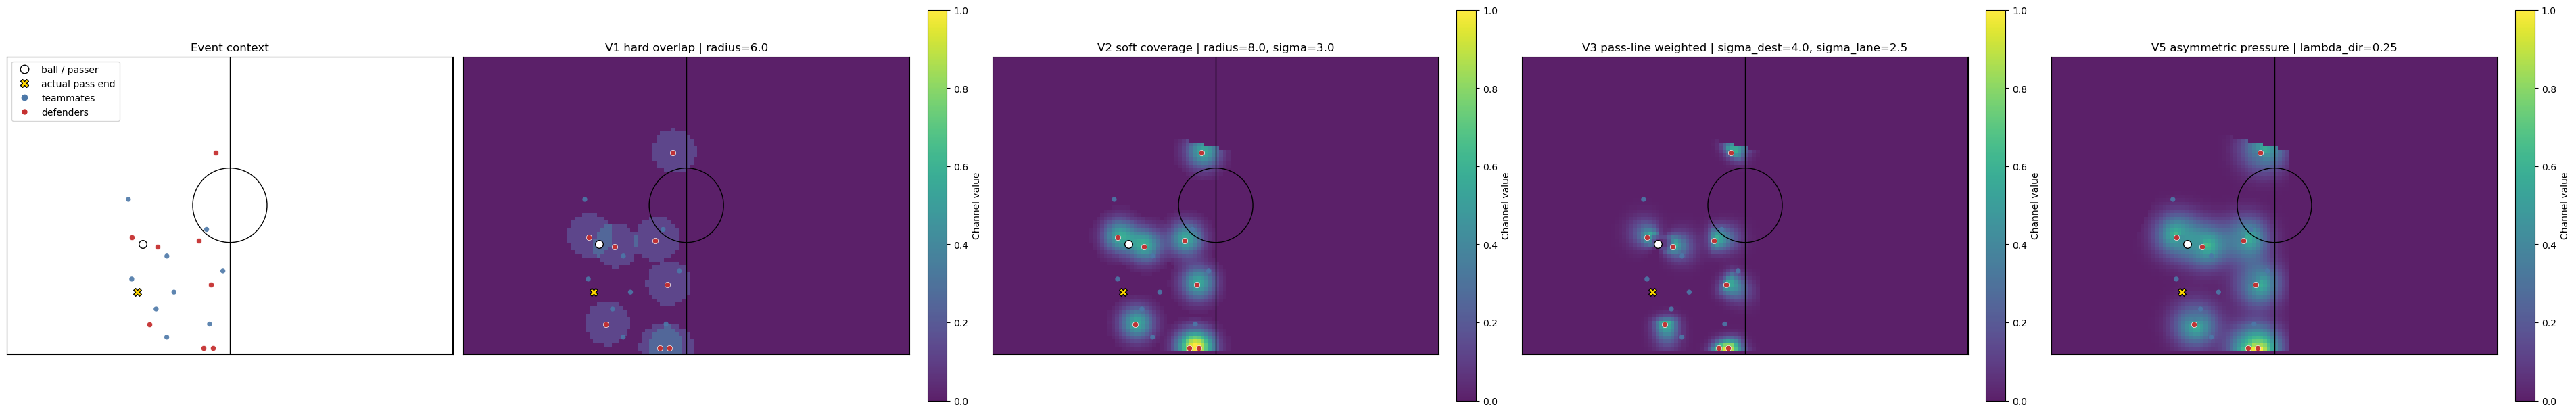

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(38, 6), constrained_layout=True)

draw_pitch(axes[0])
overlay_context(axes[0], actor_xy, end_xy, mate_xy, def_xy, show_legend=True)
axes[0].set_title("Event context")

plot_channel(axes[1], v1_channel, f"V1 hard overlap | radius={RADIUS_V1}", add_colorbar=True)
overlay_context(axes[1], actor_xy, end_xy, mate_xy, def_xy, show_legend=False)

plot_channel(axes[2], v2_channel, f"V2 soft coverage | radius={RADIUS_V2}, sigma={SIGMA_V2}", add_colorbar=True)
overlay_context(axes[2], actor_xy, end_xy, mate_xy, def_xy, show_legend=False)

plot_channel(axes[3], v3_channel, f"V3 pass-line weighted | sigma_dest={SIGMA_DEST_V3}, sigma_lane={SIGMA_LANE_V3}", add_colorbar=True)
overlay_context(axes[3], actor_xy, end_xy, mate_xy, def_xy, show_legend=False)

plot_channel(axes[4], v5_channel, f"V5 asymmetric pressure | lambda_dir={LAMBDA_DIR_V5}", add_colorbar=True)
overlay_context(axes[4], actor_xy, end_xy, mate_xy, def_xy, show_legend=False)

plt.show()


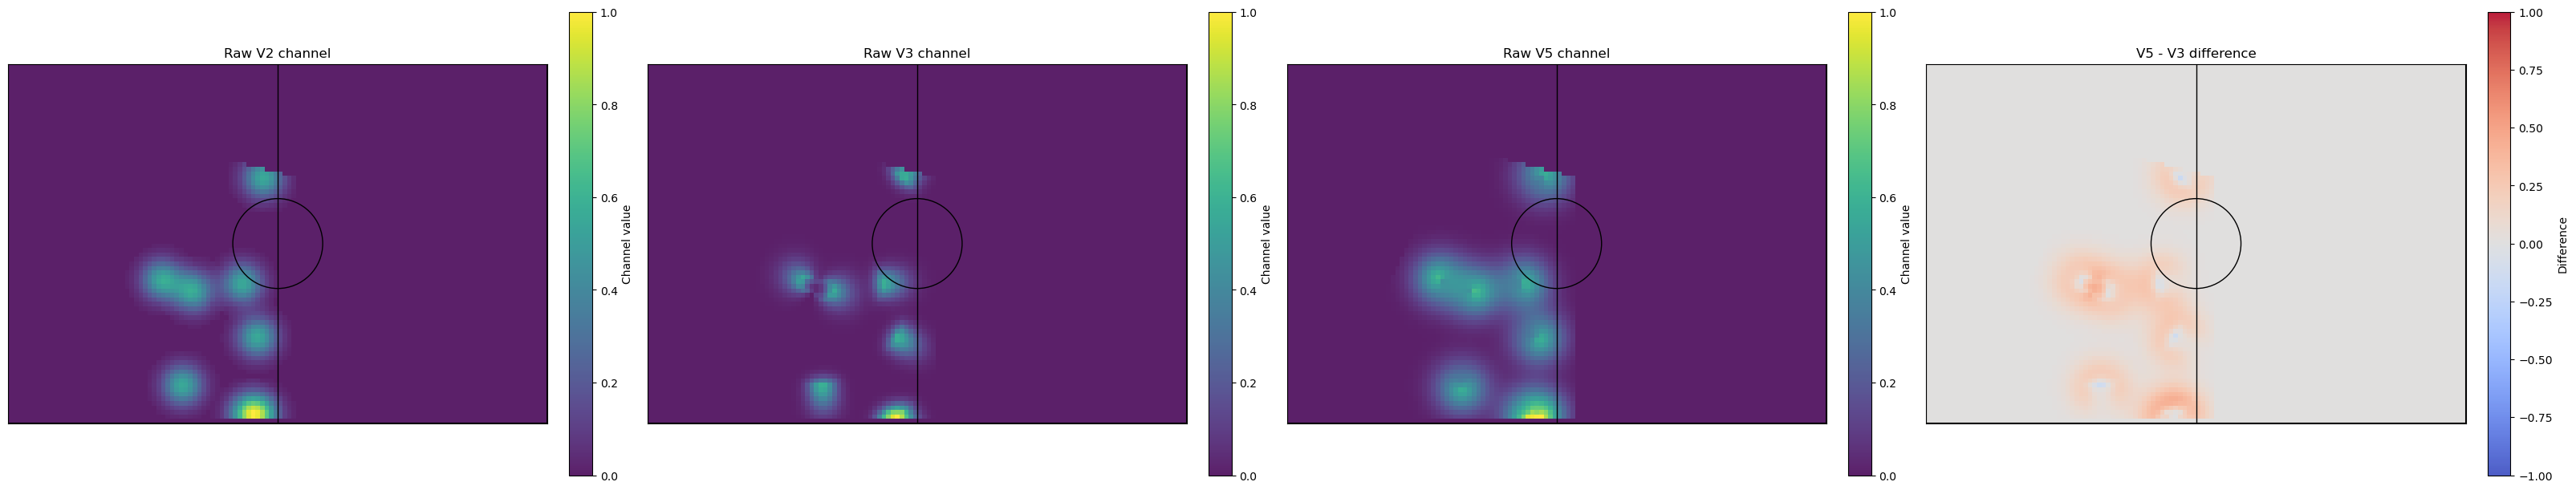

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(32, 6), constrained_layout=True)
plot_channel(axes[0], v2_channel, "Raw V2 channel", add_colorbar=True)
plot_channel(axes[1], v3_channel, "Raw V3 channel", add_colorbar=True)
plot_channel(axes[2], v5_channel, "Raw V5 channel", add_colorbar=True)
diff = v5_channel - v3_channel
im = axes[3].imshow(
    diff.T,
    origin="lower",
    extent=[0, 120, 0, 80],
    cmap="coolwarm",
    alpha=0.9,
    interpolation="nearest",
    norm=Normalize(vmin=-1.0, vmax=1.0),
)
draw_pitch(axes[3])
axes[3].set_title("V5 - V3 difference")
plt.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04, label="Difference")
plt.show()


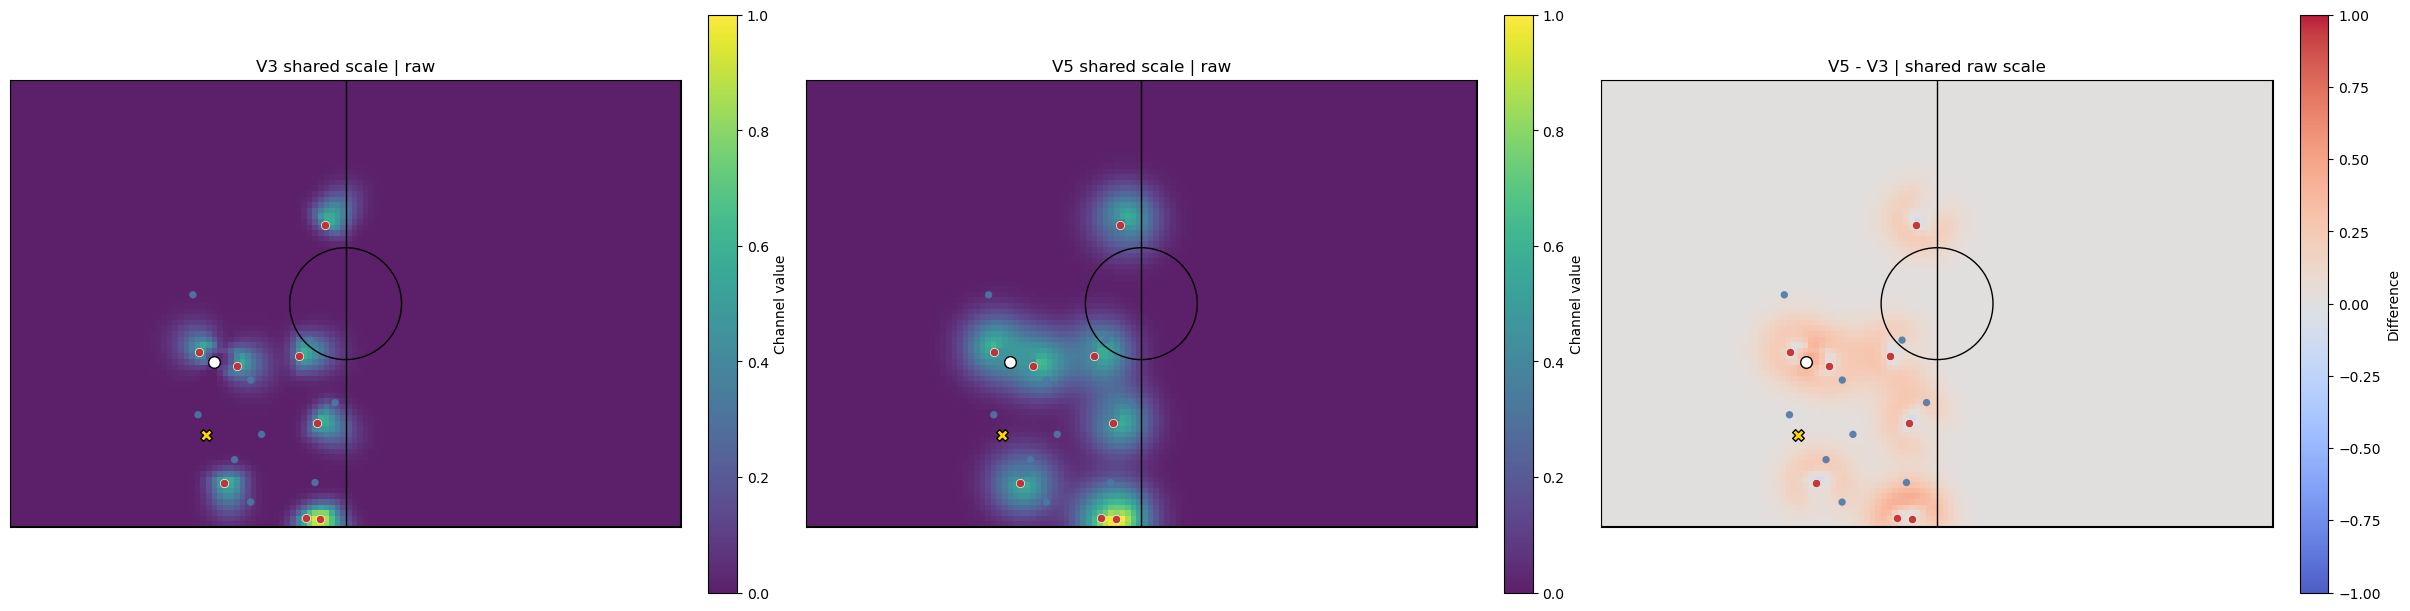

In [12]:
v3_raw = build_pass_interference_map_v3(
    passer_xy=actor_xy,
    defenders=defenders,
    grid=GRID,
    sigma_dest=SIGMA_DEST_V3,
    sigma_lane=SIGMA_LANE_V3,
    alpha=ALPHA_V3,
    beta=BETA_V3,
)
v5_raw = build_pass_interference_map_v5(
    passer_xy=actor_xy,
    defenders=defenders,
    grid=GRID,
    sigma_dest=SIGMA_DEST_V5,
    lambda_dir=LAMBDA_DIR_V5,
    side_weight=SIDE_WEIGHT_V5,
    back_weight=BACK_WEIGHT_V5,
    front_weight=FRONT_WEIGHT_V5,
)

shared_vmax = float(max(v3_raw.max(), v5_raw.max(), 1e-6))
shared_diff = v5_raw - v3_raw

fig, axes = plt.subplots(1, 3, figsize=(24, 6), constrained_layout=True)
plot_channel(axes[0], v3_raw, "V3 shared scale | raw", add_colorbar=True, vmin=0.0, vmax=shared_vmax)
overlay_context(axes[0], actor_xy, end_xy, mate_xy, def_xy, show_legend=False)
plot_channel(axes[1], v5_raw, "V5 shared scale | raw", add_colorbar=True, vmin=0.0, vmax=shared_vmax)
overlay_context(axes[1], actor_xy, end_xy, mate_xy, def_xy, show_legend=False)
im = axes[2].imshow(
    shared_diff.T,
    origin="lower",
    extent=[0, 120, 0, 80],
    cmap="coolwarm",
    alpha=0.9,
    interpolation="nearest",
    norm=Normalize(vmin=-shared_vmax, vmax=shared_vmax),
)
draw_pitch(axes[2])
overlay_context(axes[2], actor_xy, end_xy, mate_xy, def_xy, show_legend=False)
axes[2].set_title("V5 - V3 | shared raw scale")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="Difference")
plt.show()


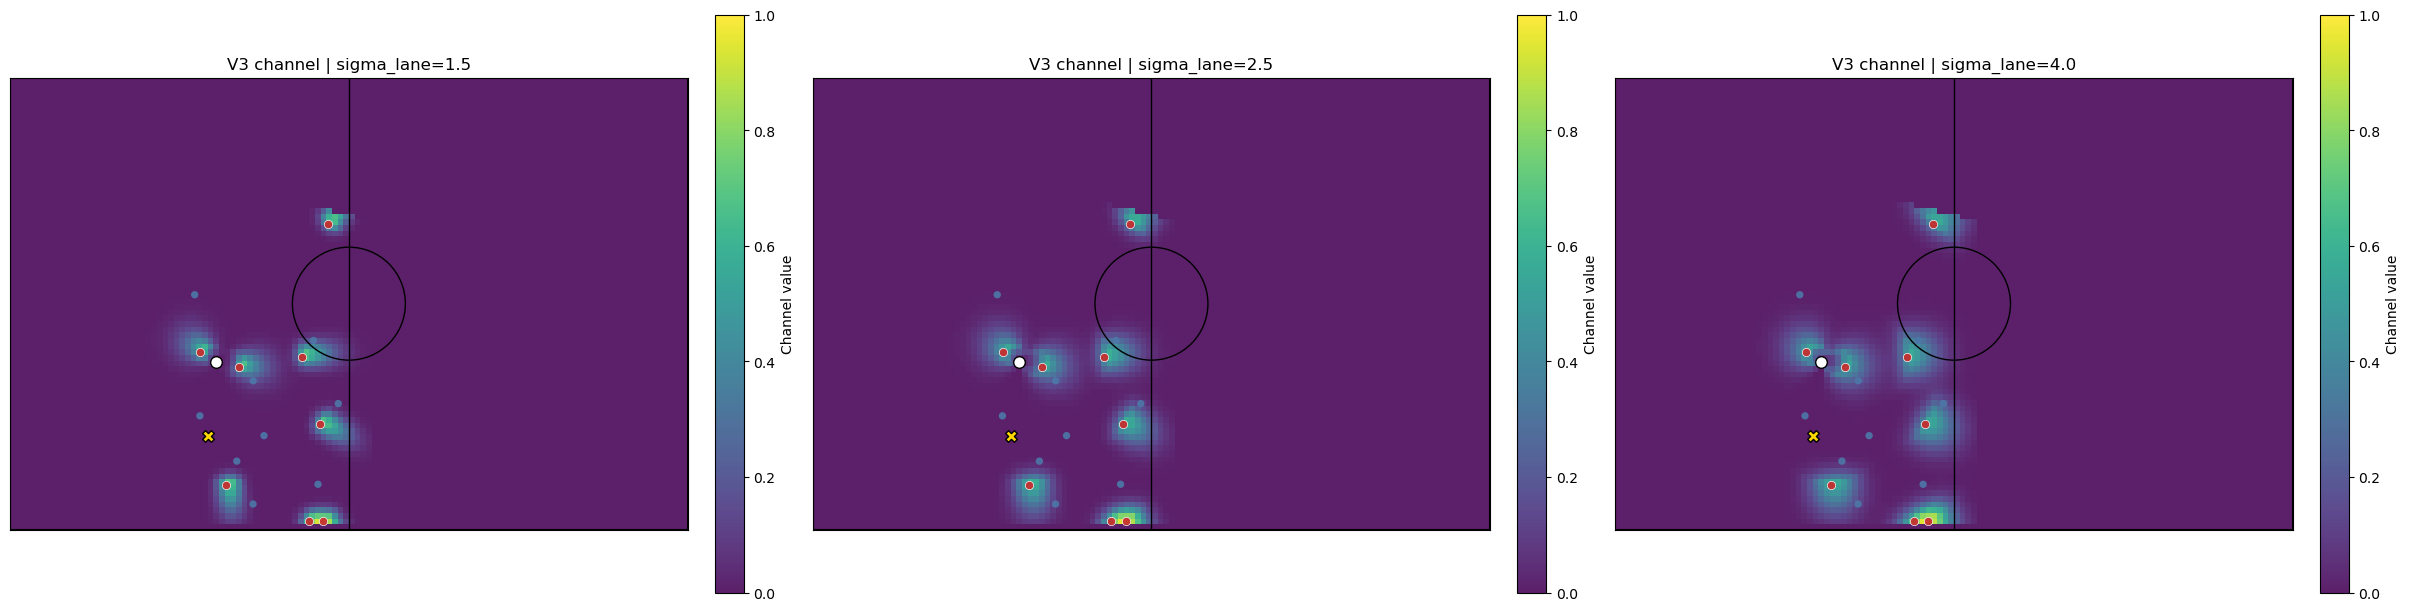

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6), constrained_layout=True)
for ax, sigma_lane in zip(axes, [1.5, 2.5, 4.0]):
    lane_channel = build_pass_interference_map_v3(
        passer_xy=actor_xy,
        defenders=defenders,
        grid=GRID,
        sigma_dest=SIGMA_DEST_V3,
        sigma_lane=sigma_lane,
        alpha=ALPHA_V3,
        beta=BETA_V3,
    )
    plot_channel(ax, lane_channel, f"V3 channel | sigma_lane={sigma_lane}", add_colorbar=True)
    overlay_context(ax, actor_xy, end_xy, mate_xy, def_xy, show_legend=False)
plt.show()


## Default Defensive Range Sensitivity Test

This block tests whether the current V5 default defensive range is too small.

In the current V5 setup, the most direct proxy for defender coverage range is `sigma_dest`, so we sweep that parameter first while keeping the rest of the V5 logic fixed.


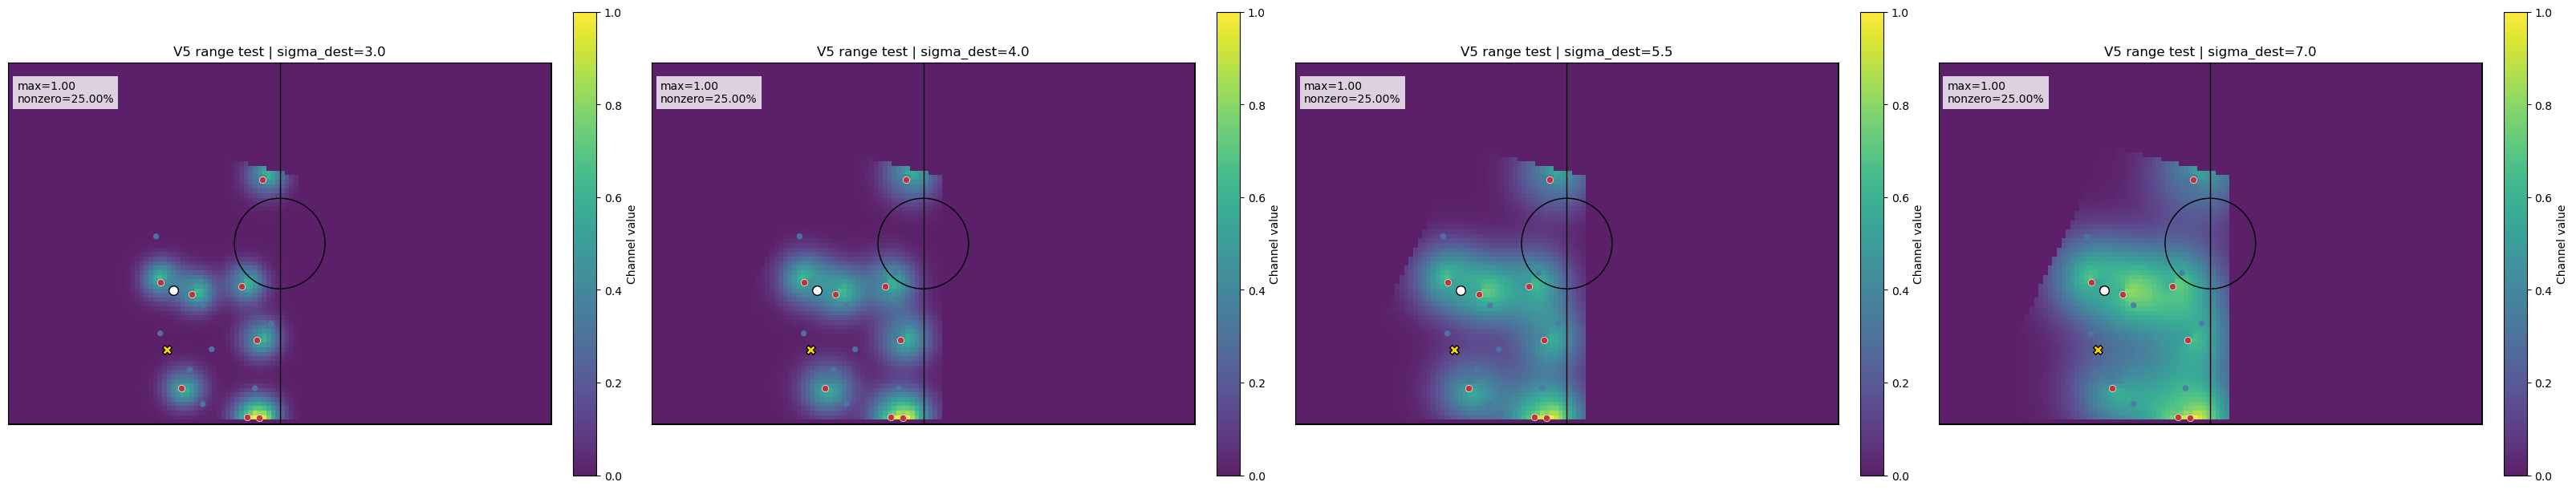

In [14]:
sigma_dest_candidates = [3.0, 4.0, 5.5, 7.0]

fig, axes = plt.subplots(1, len(sigma_dest_candidates), figsize=(8 * len(sigma_dest_candidates), 6), constrained_layout=True)

for ax, sigma_dest in zip(axes, sigma_dest_candidates):
    range_channel = build_pass_interference_map_v5(
        passer_xy=actor_xy,
        defenders=defenders,
        grid=GRID,
        sigma_dest=sigma_dest,
        lambda_dir=LAMBDA_DIR_V5,
        side_weight=SIDE_WEIGHT_V5,
        back_weight=BACK_WEIGHT_V5,
        front_weight=FRONT_WEIGHT_V5,
    )
    plot_channel(ax, range_channel, f"V5 range test | sigma_dest={sigma_dest}", add_colorbar=True)
    overlay_context(ax, actor_xy, end_xy, mate_xy, def_xy, show_legend=False)
    ax.text(
        2,
        76,
        f"max={range_channel.max():.2f}\nnonzero={(range_channel > 0).mean():.2%}",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
    )

plt.show()


In [15]:
range_summary = []
for sigma_dest in sigma_dest_candidates:
    range_channel = build_pass_interference_map_v5(
        passer_xy=actor_xy,
        defenders=defenders,
        grid=GRID,
        sigma_dest=sigma_dest,
        lambda_dir=LAMBDA_DIR_V5,
        side_weight=SIDE_WEIGHT_V5,
        back_weight=BACK_WEIGHT_V5,
        front_weight=FRONT_WEIGHT_V5,
    )
    summary = summarize_channel(range_channel).to_dict()
    summary["sigma_dest"] = sigma_dest
    range_summary.append(summary)

range_summary_df = pd.DataFrame(range_summary)[["sigma_dest", "min", "max", "mean", "nonzero_fraction", "nonzero_mean"]]
display(range_summary_df)


,sigma_dest,min,max,mean,nonzero_fraction,nonzero_mean
0,3.0,0.0,1.0,0.020895,0.25,0.083580
1,4.0,0.0,1.0,0.033474,0.25,0.133897
2,5.5,0.0,1.0,0.055624,0.25,0.222495
3,7.0,0.0,1.0,0.079925,0.25,0.319699


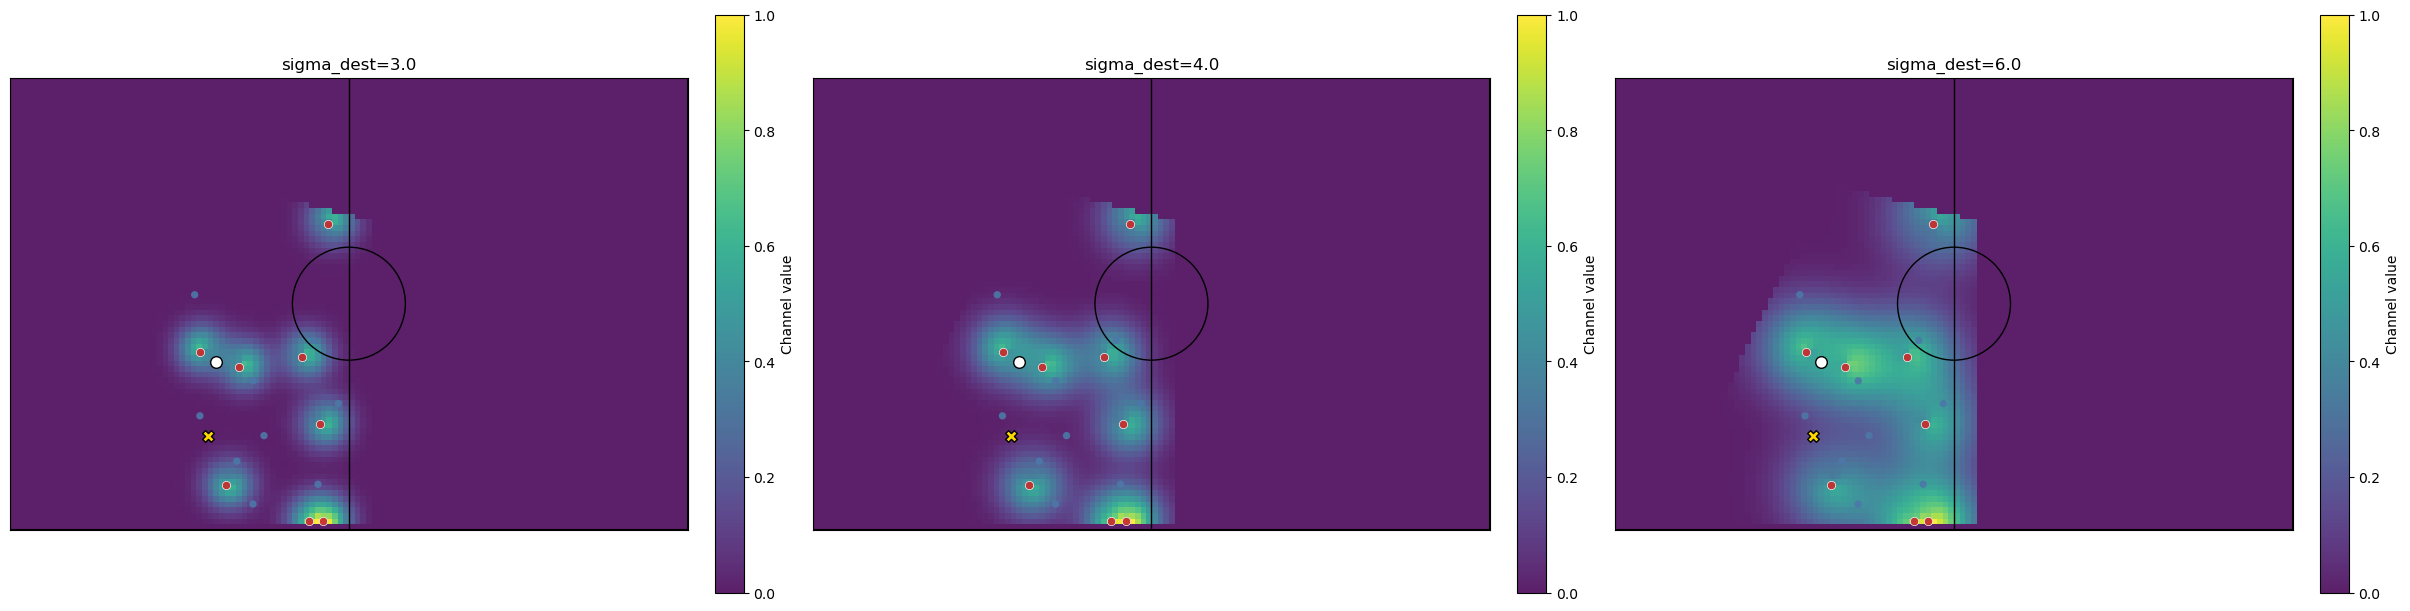

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6), constrained_layout=True)
for ax, sigma_dest in zip(axes, [3.0, 4.0, 6.0]):
    dest_channel = build_pass_interference_map_v5(
        passer_xy=actor_xy,
        defenders=defenders,
        grid=GRID,
        sigma_dest=sigma_dest,
        lambda_dir=LAMBDA_DIR_V5,
        side_weight=SIDE_WEIGHT_V5,
        back_weight=BACK_WEIGHT_V5,
        front_weight=FRONT_WEIGHT_V5,
    )
    plot_channel(ax, dest_channel, f"sigma_dest={sigma_dest}", add_colorbar=True)
    overlay_context(ax, actor_xy, end_xy, mate_xy, def_xy, show_legend=False)
plt.show()


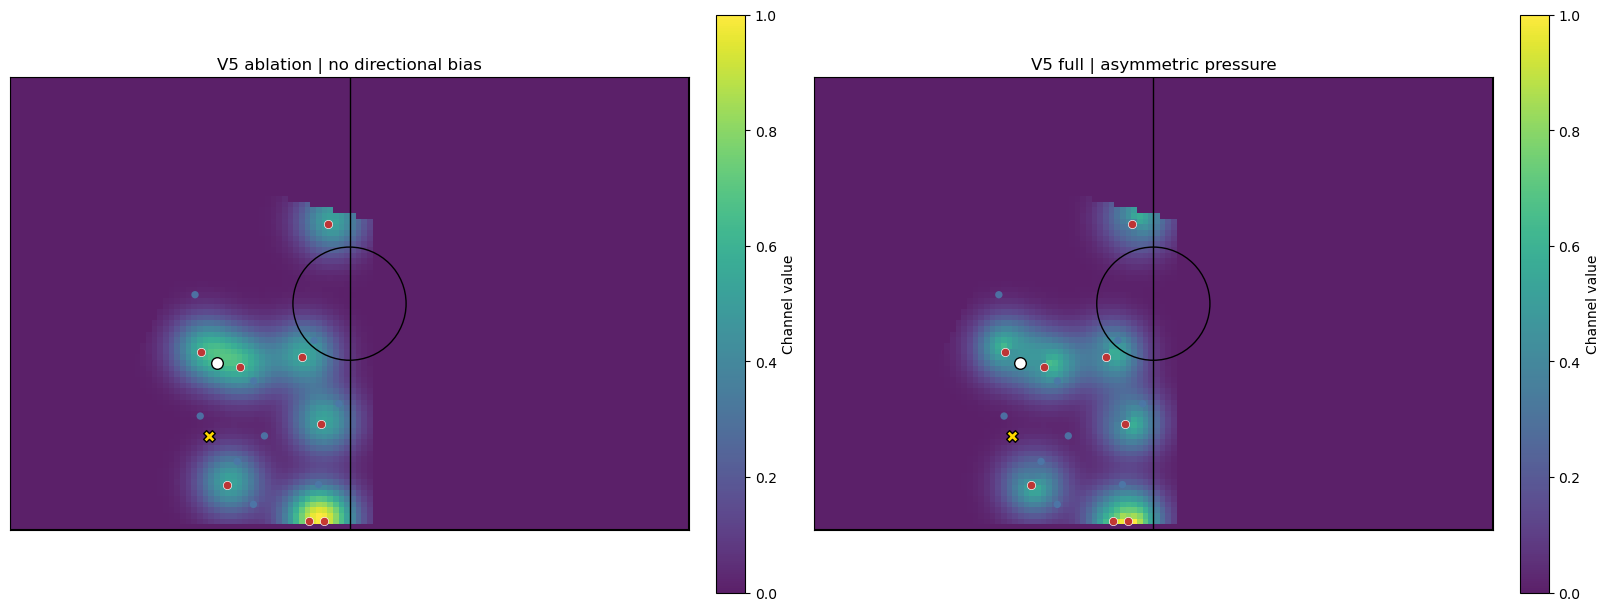

In [17]:
v5_no_direction = build_pass_interference_map_v5(
    passer_xy=actor_xy,
    defenders=defenders,
    grid=GRID,
    sigma_dest=SIGMA_DEST_V5,
    lambda_dir=0.0,
    side_weight=1.0,
    back_weight=1.0,
    front_weight=1.0,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
plot_channel(axes[0], v5_no_direction, "V5 ablation | no directional bias", add_colorbar=True)
overlay_context(axes[0], actor_xy, end_xy, mate_xy, def_xy, show_legend=False)
plot_channel(axes[1], v5_channel, "V5 full | asymmetric pressure", add_colorbar=True)
overlay_context(axes[1], actor_xy, end_xy, mate_xy, def_xy, show_legend=False)
plt.show()


## Notes

- `V1` is the original hard-circle overlap baseline.
- `V2` is a smoother defender-centered coverage channel.
- `V3` adds pass-line awareness by weighting defenders according to their distance to the passer-destination line segment and their forward position along that line.
- `V5` defines an asymmetric defender pressure field: pressure exists in all directions, but it is strongest in front, moderate on the sides, and weakest behind.


## More Leverkusen Examples

This section checks whether the V5 channel looks reasonable across several Bayer Leverkusen pass events rather than only one selected example.


In [18]:
example_indices = [0, 3, 7, 12]
example_indices = [i for i in example_indices if i < len(pass_events)]

multi_event_examples = []
for idx in example_indices:
    row = pass_events.iloc[idx]
    event_id = row["event_id"]
    ev_i = expanded_df.loc[expanded_df["event_id"] == event_id].copy()
    actor_i = ev_i.loc[ev_i["actor"] == True].iloc[0]
    teammates_i = ev_i.loc[(ev_i["actor"] == False) & (ev_i["teammate"] == True)].copy()
    defenders_i = ev_i.loc[(ev_i["actor"] == False) & (ev_i["teammate"] == False)].copy()
    visible_area_i = actor_i.get("visible_area") if isinstance(actor_i.get("visible_area"), list) else None

    actor_xy_i = xy_from_loc(actor_i["event_location"])
    end_xy_i = xy_from_loc(actor_i["end_location"])
    mate_xy_i = np.array([xy_from_loc(v) for v in teammates_i["ff_location"] if xy_from_loc(v) is not None], dtype=float) if len(teammates_i) else np.empty((0, 2), dtype=float)
    def_xy_i = np.array([xy_from_loc(v) for v in defenders_i["ff_location"] if xy_from_loc(v) is not None], dtype=float) if len(defenders_i) else np.empty((0, 2), dtype=float)

    v3_i = build_pass_interference_map_v3(
        passer_xy=actor_xy_i,
        defenders=defenders_i,
        grid=GRID,
        sigma_dest=SIGMA_DEST_V3,
        sigma_lane=SIGMA_LANE_V3,
        alpha=ALPHA_V3,
        beta=BETA_V3,
        visible_area=visible_area_i,
        apply_visibility_mask=APPLY_VISIBILITY_MASK,
    )
    v5_i = build_pass_interference_map_v5(
        passer_xy=actor_xy_i,
        defenders=defenders_i,
        grid=GRID,
        sigma_dest=SIGMA_DEST_V5,
        lambda_dir=LAMBDA_DIR_V5,
        side_weight=SIDE_WEIGHT_V5,
        back_weight=BACK_WEIGHT_V5,
        front_weight=FRONT_WEIGHT_V5,
    )

    multi_event_examples.append({
        "idx": idx,
        "event_id": event_id,
        "player_name": row["player_name"],
        "minute": row["minute"],
        "second": row["second"],
        "pass_completed": row["pass_completed"],
        "actor_xy": actor_xy_i,
        "end_xy": end_xy_i,
        "mate_xy": mate_xy_i,
        "def_xy": def_xy_i,
        "v3": v3_i,
        "v5": v5_i,
    })

pd.DataFrame([
    {
        "idx": ex["idx"],
        "event_id": ex["event_id"],
        "player_name": ex["player_name"],
        "minute": ex["minute"],
        "second": ex["second"],
        "pass_completed": ex["pass_completed"],
        "v3_max": float(ex["v3"].max()),
        "v5_max": float(ex["v5"].max()),
        "v3_nonzero_fraction": float((ex["v3"] > 0).mean()),
        "v5_nonzero_fraction": float((ex["v5"] > 0).mean()),
    }
    for ex in multi_event_examples
])


,idx,event_id,player_name,minute,second,pass_completed,v3_max,v5_max,v3_nonzero_fraction,v5_nonzero_fraction
0,0,a6f33202-5449-458f-8473-9c4274528e11,Odilon Kossonou,0,20,0.0,1.0,1.0,0.250000,0.250000
1,3,ed61d850-a665-4e5e-a9b4-fa4860cd73a9,Granit Xhaka,1,54,1.0,1.0,1.0,0.282604,0.282604
2,7,61823ed4-1479-4890-b776-23c242285441,Exequiel Alejandro Palacios,2,25,0.0,1.0,1.0,0.206979,0.208229
3,12,a5b88451-ad44-4809-a52a-f2cce2822d77,Edmond Fayçal Tapsoba,3,16,1.0,1.0,1.0,0.295625,0.306979


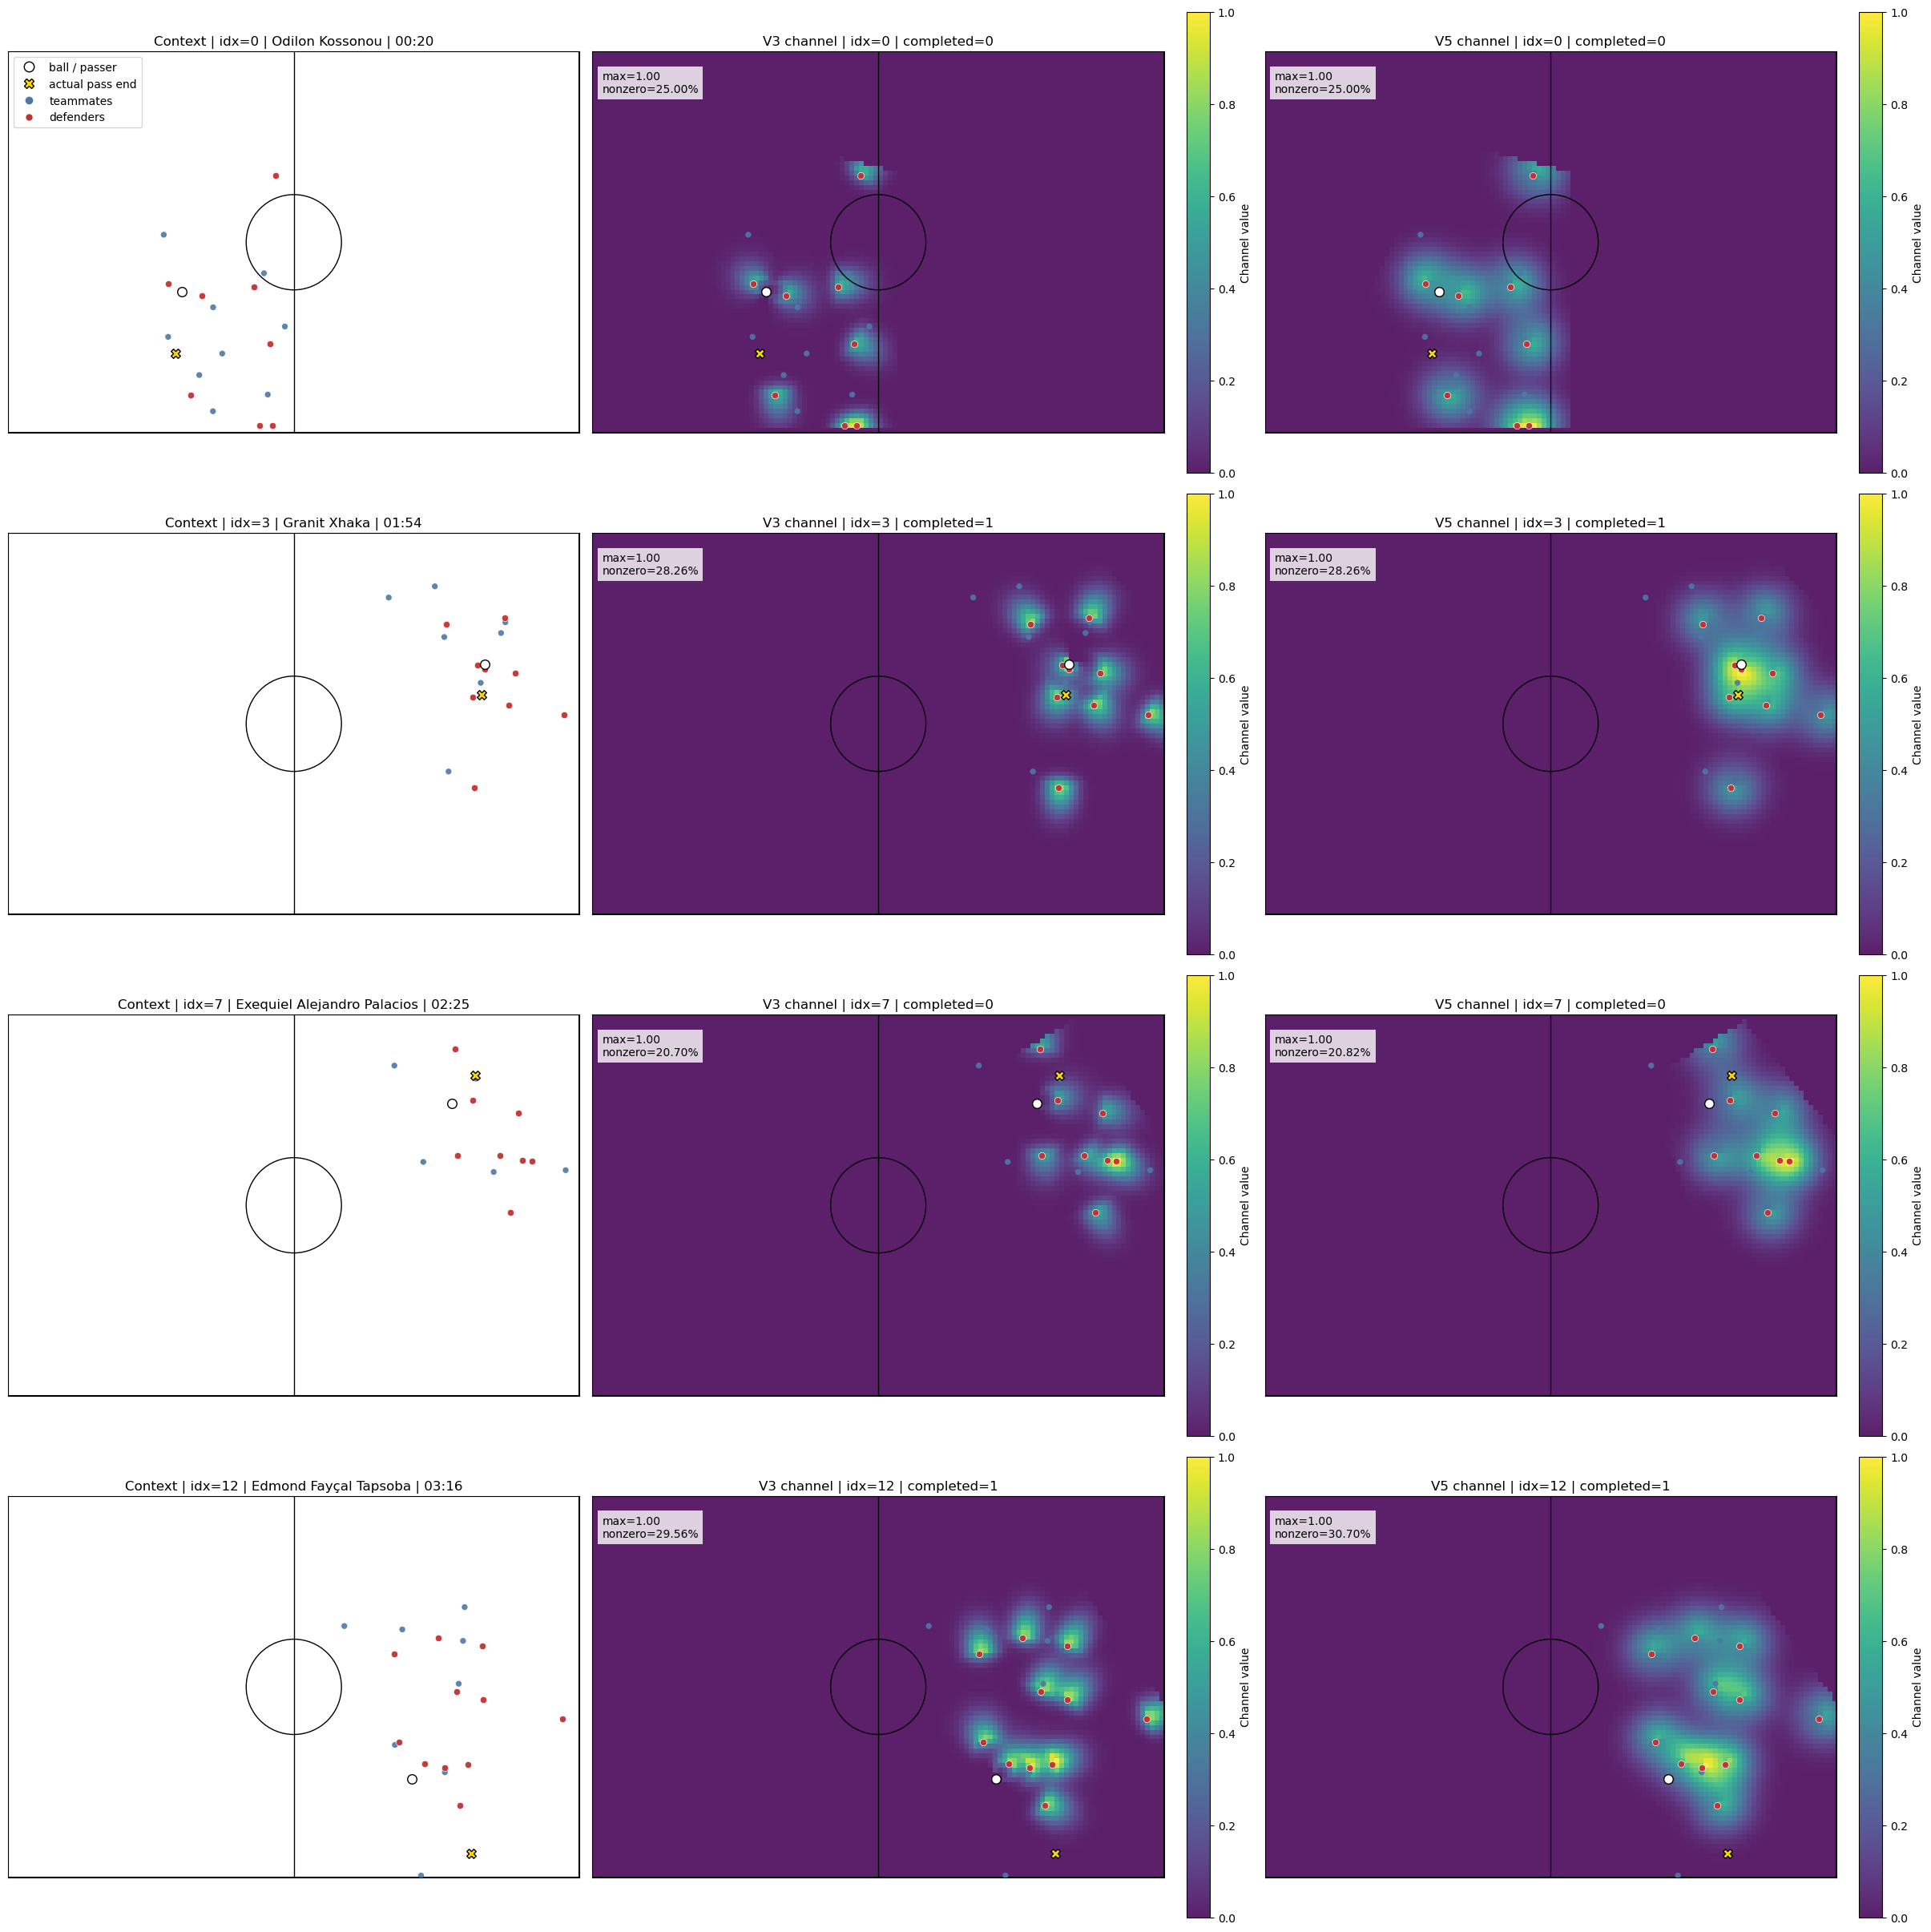

In [19]:
fig, axes = plt.subplots(len(multi_event_examples), 3, figsize=(24, 6 * len(multi_event_examples)), constrained_layout=True, squeeze=False)

for row_idx, ex in enumerate(multi_event_examples):
    ax0 = axes[row_idx, 0]
    draw_pitch(ax0)
    overlay_context(ax0, ex["actor_xy"], ex["end_xy"], ex["mate_xy"], ex["def_xy"], show_legend=(row_idx == 0))
    ax0.set_title(f"Context | idx={ex['idx']} | {ex['player_name']} | {int(ex['minute']):02d}:{int(ex['second']):02d}")

    ax1 = axes[row_idx, 1]
    plot_channel(ax1, ex["v3"], f"V3 channel | idx={ex['idx']} | completed={int(ex['pass_completed']) if pd.notna(ex['pass_completed']) else 'NA'}", add_colorbar=True)
    overlay_context(ax1, ex["actor_xy"], ex["end_xy"], ex["mate_xy"], ex["def_xy"], show_legend=False)
    ax1.text(
        2,
        76,
        f"max={ex['v3'].max():.2f}\nnonzero={(ex['v3'] > 0).mean():.2%}",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
    )

    ax2 = axes[row_idx, 2]
    plot_channel(ax2, ex["v5"], f"V5 channel | idx={ex['idx']} | completed={int(ex['pass_completed']) if pd.notna(ex['pass_completed']) else 'NA'}", add_colorbar=True)
    overlay_context(ax2, ex["actor_xy"], ex["end_xy"], ex["mate_xy"], ex["def_xy"], show_legend=False)
    ax2.text(
        2,
        76,
        f"max={ex['v5'].max():.2f}\nnonzero={(ex['v5'] > 0).mean():.2%}",
        va="top",
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
    )

plt.show()


## Focused Comparison: idx=12

This block compares `V3` and `V5` on the fixed Leverkusen example `idx=12`, with `V5` explicitly using `sigma_dest=4.0`.


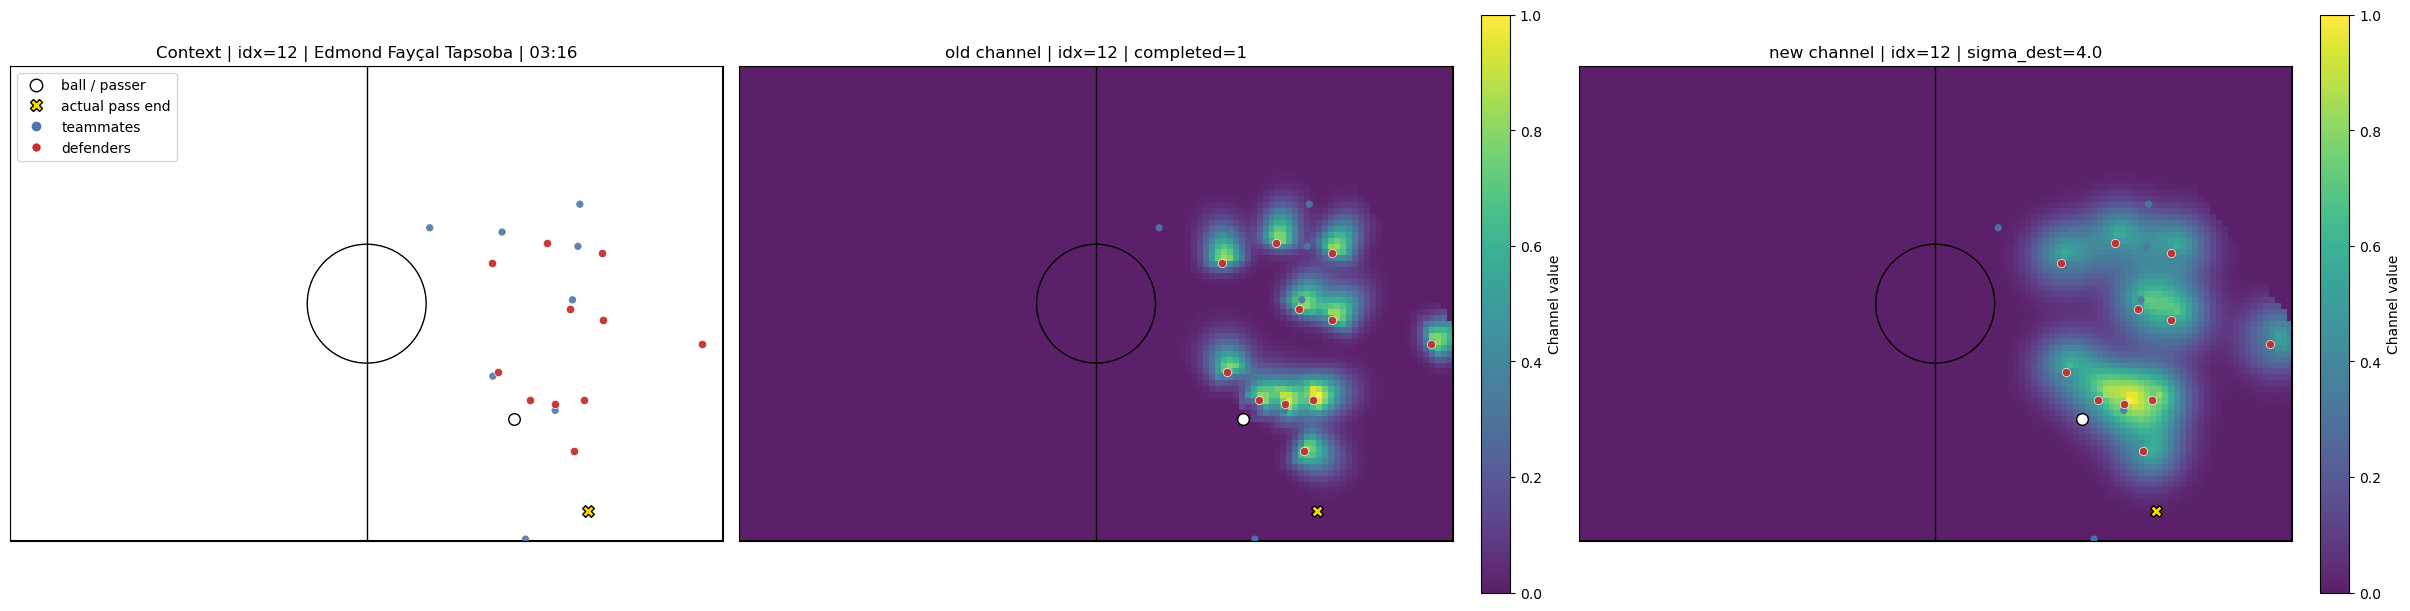

In [22]:
FOCUS_IDX = 12
focus_row = pass_events.iloc[FOCUS_IDX]
focus_event_id = focus_row["event_id"]

focus_ev = expanded_df.loc[expanded_df["event_id"] == focus_event_id].copy()
focus_actor = focus_ev.loc[focus_ev["actor"] == True].iloc[0]
focus_teammates = focus_ev.loc[(focus_ev["actor"] == False) & (focus_ev["teammate"] == True)].copy()
focus_defenders = focus_ev.loc[(focus_ev["actor"] == False) & (focus_ev["teammate"] == False)].copy()
focus_visible_area = focus_actor.get("visible_area") if isinstance(focus_actor.get("visible_area"), list) else None

focus_actor_xy = xy_from_loc(focus_actor["event_location"])
focus_end_xy = xy_from_loc(focus_actor["end_location"])
focus_mate_xy = np.array([xy_from_loc(v) for v in focus_teammates["ff_location"] if xy_from_loc(v) is not None], dtype=float) if len(focus_teammates) else np.empty((0, 2), dtype=float)
focus_def_xy = np.array([xy_from_loc(v) for v in focus_defenders["ff_location"] if xy_from_loc(v) is not None], dtype=float) if len(focus_defenders) else np.empty((0, 2), dtype=float)

focus_v3 = build_pass_interference_map_v3(
    passer_xy=focus_actor_xy,
    defenders=focus_defenders,
    grid=GRID,
    sigma_dest=SIGMA_DEST_V3,
    sigma_lane=SIGMA_LANE_V3,
    alpha=ALPHA_V3,
    beta=BETA_V3,
    visible_area=focus_visible_area,
    apply_visibility_mask=APPLY_VISIBILITY_MASK,
)
focus_v5 = build_pass_interference_map_v5(
    passer_xy=focus_actor_xy,
    defenders=focus_defenders,
    grid=GRID,
    sigma_dest=4.0,
    lambda_dir=LAMBDA_DIR_V5,
    side_weight=SIDE_WEIGHT_V5,
    back_weight=BACK_WEIGHT_V5,
    front_weight=FRONT_WEIGHT_V5,
)

fig, axes = plt.subplots(1, 3, figsize=(24, 6), constrained_layout=True)

draw_pitch(axes[0])
overlay_context(axes[0], focus_actor_xy, focus_end_xy, focus_mate_xy, focus_def_xy, show_legend=True)
axes[0].set_title(f"Context | idx=12 | {focus_row['player_name']} | {int(focus_row['minute']):02d}:{int(focus_row['second']):02d}")

plot_channel(axes[1], focus_v3, f"old channel | idx=12 | completed={int(focus_row['pass_completed']) if pd.notna(focus_row['pass_completed']) else 'NA'}", add_colorbar=True)
overlay_context(axes[1], focus_actor_xy, focus_end_xy, focus_mate_xy, focus_def_xy, show_legend=False)

plot_channel(axes[2], focus_v5, "new channel | idx=12 | sigma_dest=4.0", add_colorbar=True)
overlay_context(axes[2], focus_actor_xy, focus_end_xy, focus_mate_xy, focus_def_xy, show_legend=False)

plt.show()


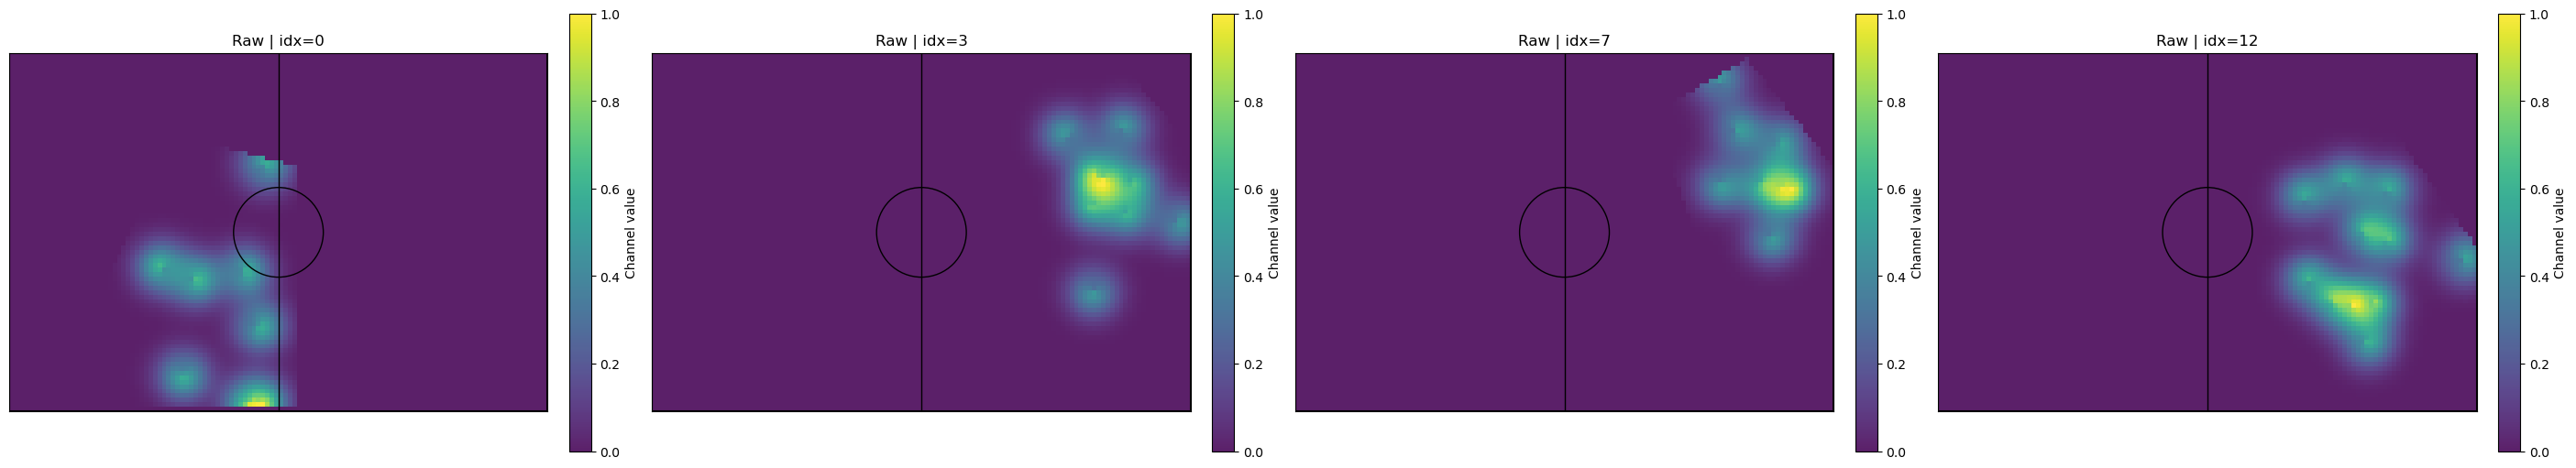

In [23]:
fig, axes = plt.subplots(1, len(multi_event_examples), figsize=(7 * len(multi_event_examples), 5), constrained_layout=True)
if len(multi_event_examples) == 1:
    axes = [axes]

for ax, ex in zip(axes, multi_event_examples):
    plot_channel(ax, ex["v5"], f"Raw | idx={ex['idx']}", add_colorbar=True)

plt.show()
